# Датасет Iris Species

In [3310]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Iris.csv')

## Некоторая информация по датасету

In [3311]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


- **датасет чистый (нет пропусков);**
- **размер - 150 строк на 6 колонок (где 1-я - id, следующие 4 - признаки, последняя - класс)**

In [3312]:
print(df.describe())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [3313]:
print(df.describe(include='str'))

            Species
count           150
unique            3
top     Iris-setosa
freq             50


In [3314]:
df_species = df['Species'].value_counts()
print(df_species)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


- **распределение классов равномерное (баланс оптимален)**

In [3315]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


## Подготовка данных

### Датасет простой, поэтому данные уже очищены. Осталось только закодировать колонку Species и масштабировать их

**используем label encoding**

In [3316]:
df['Species'] = df['Species'].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


### Теперь делим

In [3317]:
df_X = df.drop(columns=['Species','Id'])
df_Y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(df_X, df_Y, test_size=0.25, random_state=42)

### Теперь масштабируем

**это нужно, т.к. диапазоны у признаков отличаются**

In [3318]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- почему масштабирование важно для KNN --- т.к. это метрическая модель, и масштаб критично влияет на расстояние. Если бы мы использовали неотмасштабированные данные, то могли бы столкнуться с проблемой неравномерного расположения точек в n-мерном пространстве, где 1 из признаков влияет сильнее/слабее другого (масштаб оси этого признака больше/меньше масштаба для других осей соответственно);
- почему нельзя подбирать параметры на тестовой выборке --- это создает риск переобучения, так как модель KNN в качестве параметров использует всю выборку при классификации.

## Обучение

### протестируем разные патаметры

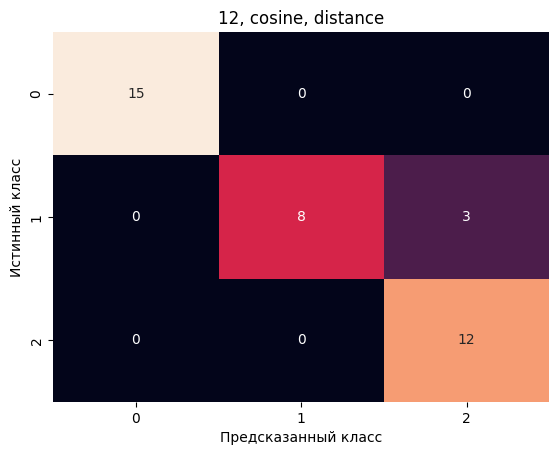

In [3319]:
result = list()

for k in range(3, 15, 3):
    for metric in ['euclidean', 'manhattan', 'minkowski', 'cosine']:
        for weight in ['uniform', 'distance']:
            classifier = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric, p=2 if metric != 'minkowski' else 3)
            classifier.fit(X_train, y_train)

            y_pred = classifier.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)

            result.append({'K_param': k, 'Metric': metric, 'Weight': weight, 'Accuracy': accuracy})

#вывод для последнего
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.title(f'{k}, {metric}, {weight}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


In [3320]:
df_result = pd.DataFrame(result)
print(df_result)

    K_param     Metric    Weight  Accuracy
0         3  euclidean   uniform  1.000000
1         3  euclidean  distance  1.000000
2         3  manhattan   uniform  1.000000
3         3  manhattan  distance  1.000000
4         3  minkowski   uniform  1.000000
5         3  minkowski  distance  1.000000
6         3     cosine   uniform  0.894737
7         3     cosine  distance  0.894737
8         6  euclidean   uniform  1.000000
9         6  euclidean  distance  1.000000
10        6  manhattan   uniform  1.000000
11        6  manhattan  distance  1.000000
12        6  minkowski   uniform  1.000000
13        6  minkowski  distance  1.000000
14        6     cosine   uniform  0.894737
15        6     cosine  distance  0.921053
16        9  euclidean   uniform  1.000000
17        9  euclidean  distance  1.000000
18        9  manhattan   uniform  1.000000
19        9  manhattan  distance  1.000000
20        9  minkowski   uniform  1.000000
21        9  minkowski  distance  1.000000
22        9

In [3321]:
print(df_result['Accuracy'].value_counts())

Accuracy
1.000000    24
0.894737     4
0.921053     4
Name: count, dtype: int64


**Как-то все слишком хорошо и искусственно (неудивительно конечно, исходя из того, какой датасет я выбрал). Так что попробую что-то поинтереснее**

# Датасет Winequality-red

In [3322]:
df = pd.read_csv('winequality-red.csv')

## Некоторая информация по датасету

In [3323]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


- **датасет чистый (нет пропусков);**
- **размер - 1599 строк на 12 колонок (где первые 11 - признаки, последняя - качество)**

In [3324]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [3325]:
df_species = df['quality'].value_counts()
print(df_species)

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


- **распределение классов неравномерное. Делить нужно будет таким образом, чтобы соотношение данных друг к другу оставалось примерно таким же. Также отсутствуют некоторые из классов (оценки 1, 2, 9, 10), что не повиляет на мое исселование до тех пор, пока оно проводится в рамках текущего датасета, но станет критичным при попытке классификации других данных, предполагающих наличие данных классов**

получается главный недостаток чистого knn (без весов например) - он привязан к равномерности и наличию всех классов. Ведь если брать данные неравномерные, то тогда может быть такое событие: пускай у нас один класс занимает 80% дата сета а второй 20%. Тогда если мы классифицируем какой-то x, который относится ко второму классу, и если у этого икса будет хотя бы небольшое отклонение в сторону первого, то модель предпочтёт классифицировать как обьект первого класса просто потому, что его обьектов этого класса больше, и даже небольшое отклонение может приблизить его первому класуу, и модель как-бы будет предпочитать этот класс.

И у меня ещё появилась идея небольшая насчёт решения этой проблемы – что если при рассчете веса для каждого соседа учитывать его класс. И таким образом, если два разноклассовых соседа находится на одинаковом расстоянии от рассматриваемого объекта, и один из более редкого класса, а второй - из более частого, то отдавать небольшой приоритет в весе именно соседу редкого класса. Ну и по-хорошему тут надо учитывать ещё количество соседей с каждого класса.

In [3326]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

## Подготовка данных

### Нужно масштабировать данные

### Делим (обязательно учитывая неравномерность распределения классов)

In [3327]:
df_X = df.drop(columns='quality')
df_Y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(df_X, df_Y, test_size=0.25, random_state=42, stratify=df_Y)


# проверим равномерность распределения
print(y_train.value_counts() / df_Y.value_counts())

quality
5    0.750367
6    0.749216
7    0.748744
4    0.754717
8    0.722222
3    0.800000
Name: count, dtype: float64


### Теперь масштабируем

**это нужно, т.к. диапазоны у признаков отличаются**

In [3328]:
scaler = StandardScaler()

# без масштабирования максимальная точность получилась 0.6425
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Обучение

### протестируем разные патаметры

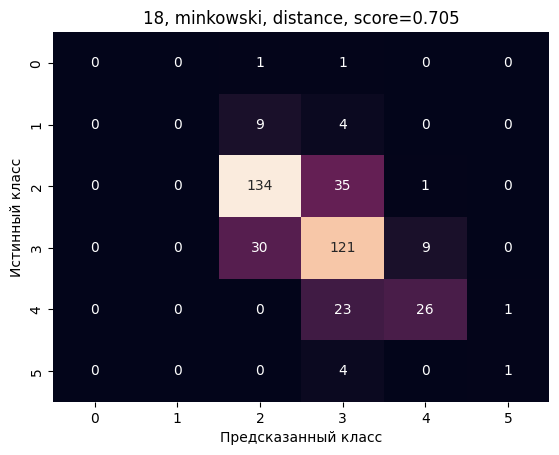

In [3329]:
result = list()
best_result = dict()
current_accuracy = 0

for k in range(5, 30):
    for metric in ['euclidean', 'manhattan', 'minkowski', 'cosine']:
        for weight in ['uniform', 'distance']:
            classifier = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric, p=2 if metric != 'minkowski' else 4.5)
            classifier.fit(X_train, y_train)

            y_pred = classifier.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)

            result.append({'K_param': k, 'Metric': metric, 'Weight': weight, 'Accuracy': accuracy})

            if accuracy > current_accuracy:
                best_result['cm'] = confusion_matrix(y_test, y_pred)
                best_result['k'] = k
                best_result['metric'] = metric
                best_result['weight'] = weight
                best_result['accuracy'] = accuracy
                current_accuracy = accuracy


# вывод для лучшего

sns.heatmap(best_result['cm'], annot=True, fmt='d', cbar=False)
plt.title(f'{best_result['k']}, {best_result['metric']}, {best_result['weight']}, score={best_result['accuracy']}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


In [3330]:
df_result = pd.DataFrame(result)
print(df_result)

     K_param     Metric    Weight  Accuracy
0          5  euclidean   uniform    0.6025
1          5  euclidean  distance    0.6525
2          5  manhattan   uniform    0.5825
3          5  manhattan  distance    0.6650
4          5  minkowski   uniform    0.6025
..       ...        ...       ...       ...
195       29  manhattan  distance    0.6625
196       29  minkowski   uniform    0.5875
197       29  minkowski  distance    0.6800
198       29     cosine   uniform    0.5825
199       29     cosine  distance    0.6775

[200 rows x 4 columns]


In [3331]:
best_result.pop('cm')
print(best_result)

{'k': 18, 'metric': 'minkowski', 'weight': 'distance', 'accuracy': 0.705}


**Теперь можно сравнить результаты разных гипермапаметров**

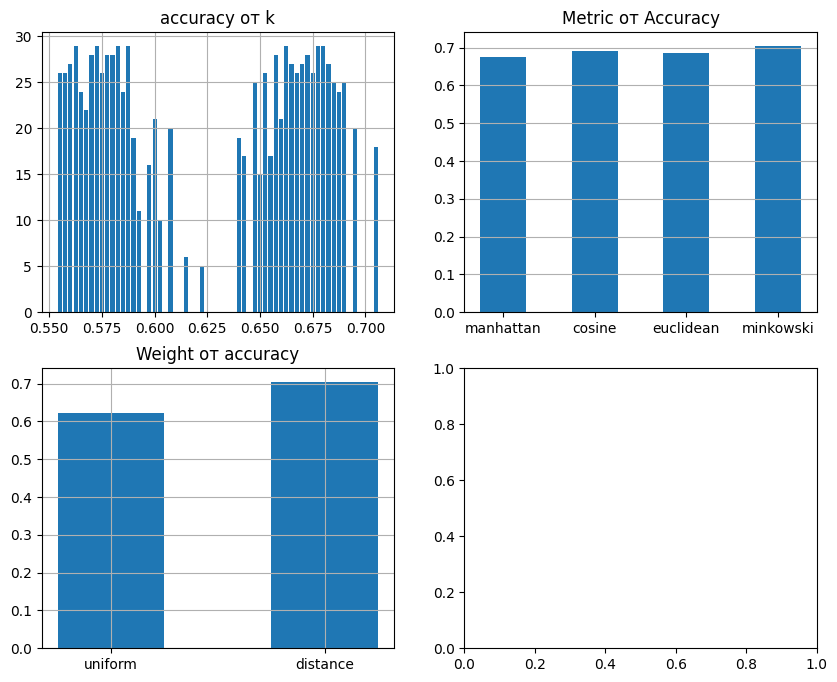

In [3332]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes[0,0].bar(df_result['Accuracy'], df_result['K_param'], width=0.002)
axes[0,0].grid(True)
axes[0,0].set_title('accuracy от k')


df_sorted = df_result.sort_values('Accuracy', ascending=True)

axes[0,1].bar(df_sorted['Metric'], df_sorted['Accuracy'], width=0.5)
axes[0,1].set_title('Metric от Accuracy')
axes[0,1].tick_params(axis='x')
axes[0,1].grid(True, axis='y')

axes[1,0].bar(df_sorted['Weight'], df_sorted['Accuracy'], width=0.5)
axes[1,0].grid(True)
axes[1,0].set_title('Weight от accuracy')
plt.show()

## Итого

- **как я ранее упомянул, у моей модели есть ограничения на классы 1,2,9,10 и также некоторая неравномерость распределения данных. Это важно учитывать при применении модели к другим данным** 
- **также я получил, что результативнее всего оказались модели с метрикой Минковского и весами distance**
    - **Веса - можно обьяснить неравномерным распределением данных, в результате чего модель "отдает предпочтение" классам, где данных больше (т.к. соседей таких классов попросту больше). И корректировка весов помогает увеличивать влияние тех классов, которых меньше, если они находятся ближе, что создает больший балланс при классификации**
    - **Метрика - усиливает вклад признаков с большим расбросом**